In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
print("Imports done!")

Imports done!


In [2]:
df = pd.read_csv("Dataset_B.csv")

targets = ['r1','r2','r3','D1','D2','D3']
feature_cols = [c for c in df.columns if c not in targets]

X = df[feature_cols].values
Y = df[targets].values

# Handle NaNs
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

# Remove zero variance
stds = X.std(axis=0)
mask = stds > 1e-12
X = X[:, mask]

# Normalize
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
Xn = scaler_X.fit_transform(X)
Yn = scaler_Y.fit_transform(Y)

# Split
X_train, X_test, Y_train, Y_test = train_test_split(
    Xn, Yn, test_size=0.2, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)

print("Data loaded!")
print("X shape:", X_train_t.shape)

Data loaded!
X shape: torch.Size([3918, 20])


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10960\2924584542.py:10: RuntimeWarning: Mean of empty slice
  col_means = np.nanmean(X, axis=0)


In [3]:
class InverseNN_Dropout(nn.Module):
    def __init__(self, in_dim, out_dim=6, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [4]:
in_dim = X_train.shape[1]
model = InverseNN_Dropout(in_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 500
best_loss = np.inf
best_model_state = model.state_dict()
loss_curve = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, Y_train_t)
    if torch.isnan(loss):
        continue
    loss.backward()
    optimizer.step()
    loss_curve.append(loss.item())
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_model_state = model.state_dict()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

model.load_state_dict(best_model_state)
print("Training complete!")

Epoch 0, Loss = 1.001620
Epoch 50, Loss = 0.519558
Epoch 100, Loss = 0.439745
Epoch 150, Loss = 0.405693
Epoch 200, Loss = 0.379434
Epoch 250, Loss = 0.361812
Epoch 300, Loss = 0.350207
Epoch 350, Loss = 0.338319
Epoch 400, Loss = 0.326703
Epoch 450, Loss = 0.316491
Training complete!


In [5]:
n_runs = 50

# Keep dropout ON during prediction
model.train()

all_preds = []
with torch.no_grad():
    for _ in range(n_runs):
        pred = model(X_test_t).numpy()
        all_preds.append(pred)

all_preds = np.array(all_preds)  # shape: (50, n_samples, 6)

# Mean and std
mean_pred = np.mean(all_preds, axis=0)
std_pred  = np.std(all_preds, axis=0)

# Inverse transform
mean_pred = scaler_Y.inverse_transform(mean_pred)
std_pred  = std_pred * scaler_Y.scale_
Y_true    = scaler_Y.inverse_transform(Y_test)

print("Predictions done!")
print("Mean pred shape:", mean_pred.shape)
print("Std pred shape:", std_pred.shape)

Predictions done!
Mean pred shape: (980, 6)
Std pred shape: (980, 6)


In [8]:
targets = ['r1','r2','r3','D1','D2','D3']

print("===== Uncertainty Quantification Results =====")
for i, t in enumerate(targets):
    r2  = r2_score(Y_true[:, i], mean_pred[:, i])
    avg_std = np.mean(std_pred[:, i])
    print(f"{t}: R²={r2:.4f} | Avg Uncertainty=±{avg_std:.4f}")

===== Uncertainty Quantification Results =====
r1: R²=0.7176 | Avg Uncertainty=±0.2397
r2: R²=0.6141 | Avg Uncertainty=±0.2925
r3: R²=0.2339 | Avg Uncertainty=±0.2257
D1: R²=0.9285 | Avg Uncertainty=±0.0011
D2: R²=0.9782 | Avg Uncertainty=±0.0009
D3: R²=0.5731 | Avg Uncertainty=±0.0009


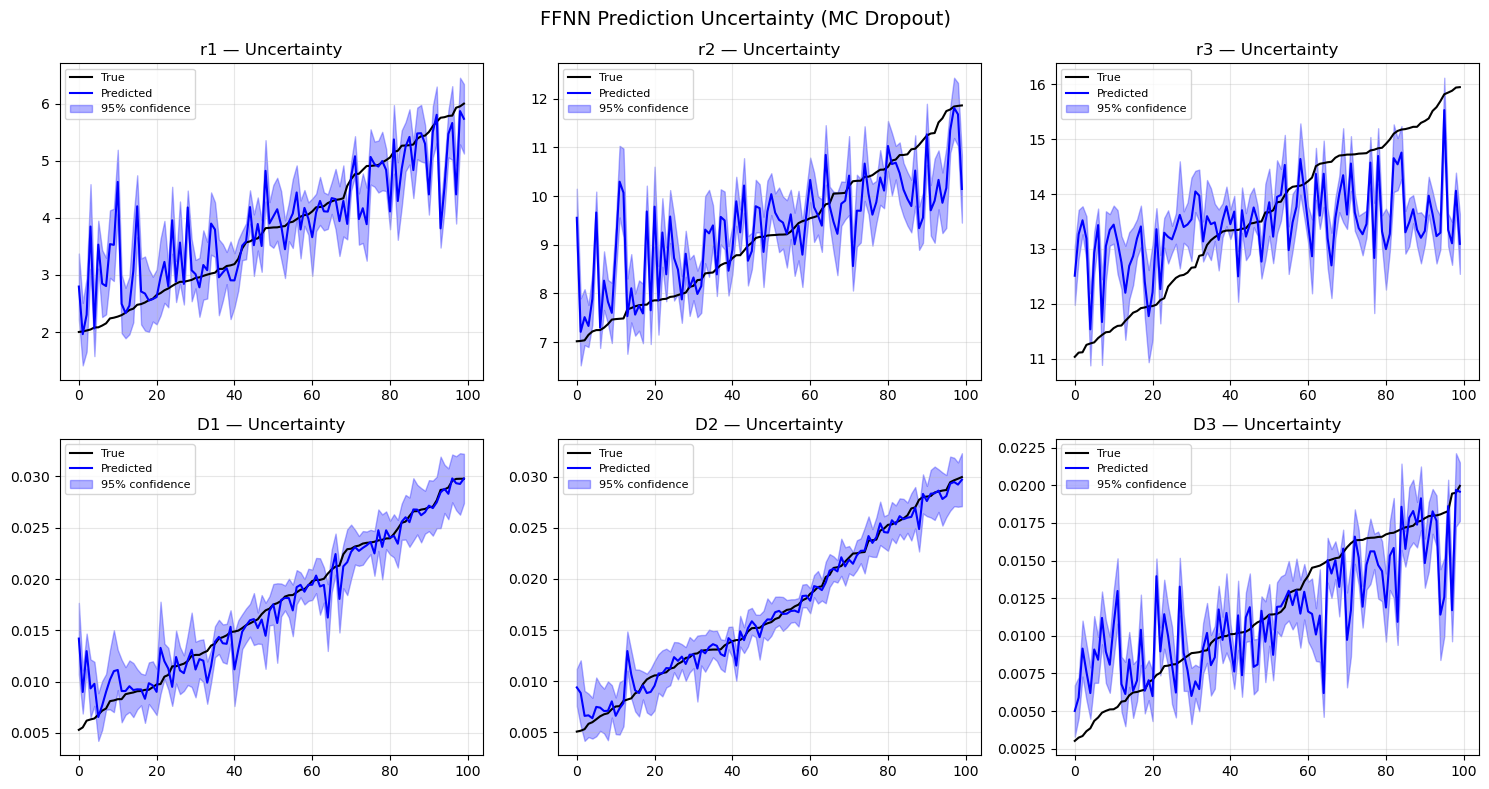

Plot saved!


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, t in enumerate(targets):
    # Sort by true value for clean plot
    sort_idx = np.argsort(Y_true[:100, idx])
    true_sorted = Y_true[:100, idx][sort_idx]
    mean_sorted = mean_pred[:100, idx][sort_idx]
    std_sorted  = std_pred[:100, idx][sort_idx]

    axes[idx].plot(true_sorted, label='True', color='black')
    axes[idx].plot(mean_sorted, label='Predicted', color='blue')
    axes[idx].fill_between(
        range(100),
        mean_sorted - 2*std_sorted,
        mean_sorted + 2*std_sorted,
        alpha=0.3, color='blue', label='95% confidence'
    )
    axes[idx].set_title(f'{t} — Uncertainty')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('FFNN Prediction Uncertainty (MC Dropout)', fontsize=14)
plt.tight_layout()
plt.savefig('uncertainty_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [10]:
np.save("uncertainty_mean.npy", mean_pred)
np.save("uncertainty_std.npy", std_pred)
np.save("uncertainty_true.npy", Y_true)
print("Saved!")

Saved!
